In [2]:
import pandas as pd
import numpy as np
import gc
from datasets import Dataset, load_from_disk
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, f1_score, multilabel_confusion_matrix
import random 
import warnings
import transformers
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore', category=FutureWarning)
transformers.logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# RoBERTa-base (100k Sample) - Final Model

#### Load tokenized dataset

In [3]:
# Dataset stays on disk, rows load only when needed
tokenized_dataset = load_from_disk('../data/tokenized_for_roberta')
print(f"Loaded {len(tokenized_dataset):,} rows")

aspect_cols = [
             'product_quality_positive', 'product_quality_negative',
             'service_positive', 'service_negative',
             'wait_time_positive', 'wait_time_negative',
             'price_value_positive', 'price_value_negative',
             'cleanliness_positive', 'cleanliness_negative',
             'atmosphere_positive', 'atmosphere_negative',
             'general_positive', 'general_negative'
]            

# Split for test set
random.seed(2)
sample = tokenized_dataset.select(random.sample(range(len(tokenized_dataset)), 100_000))
split = sample.train_test_split(test_size=0.1, seed=2)
test_subset = split['test']
print(f"\nTest size: {len(test_subset):,}")

Loading dataset from disk:   0%|          | 0/35 [00:00<?, ?it/s]

Loaded 22,614,379 rows

Test size: 10,000


#### Evaluation Metrics

In [4]:
# Define metrics
def compute_metrics(pred):
    """Compute evaluation metrics for multi-label classification."""
    labels = pred.label_ids
    preds = (pred.predictions > 0.5).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

## Test Set Results

In [5]:
model = RobertaForSequenceClassification.from_pretrained(
    '../models/roberta_final',
    num_labels=len(aspect_cols),
    problem_type="multi_label_classification"
).to(device)
model.eval()

test_subset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
loader = DataLoader(test_subset, batch_size=128)

all_preds = []
with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**batch).logits
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        all_preds.append(preds)

y_pred = np.vstack(all_preds)
y_true = np.array(test_subset['labels'])

print("RoBERTa-base (100k Sample) - Test Set")
print()
print(f"F1 Score (weighted): {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Score (macro):    {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=aspect_cols, zero_division=0))

RoBERTa-base (100k Sample) - Test Set

F1 Score (weighted): 0.9283
F1 Score (macro):    0.8761

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.95      0.96      0.96      3117
product_quality_negative       0.85      0.79      0.82       771
        service_positive       0.96      0.97      0.96      2416
        service_negative       0.90      0.85      0.87       677
      wait_time_positive       0.93      0.91      0.92      1236
      wait_time_negative       0.85      0.80      0.82       444
    price_value_positive       0.93      0.94      0.93      1106
    price_value_negative       0.84      0.76      0.80       366
    cleanliness_positive       0.94      0.93      0.94       522
    cleanliness_negative       0.82      0.79      0.80       168
     atmosphere_positive       0.93      0.95      0.94       805
     atmosphere_negative       0.81      0.75      0.78       201
        general_positi

## Manually Labeled Validation Set Results

In [6]:
df_val = pd.read_csv('../data/manual_absa_eval_reviews.csv')

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len, return_tensors="pt")
    def __len__(self):
        return self.encodings["input_ids"].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
val_dataset = ReviewDataset(df_val["text"].fillna(""), tokenizer)
loader = DataLoader(val_dataset, batch_size=64)

all_preds = []
with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        all_preds.append(preds)

y_pred_val = np.vstack(all_preds)
y_true_val = df_val[aspect_cols].values

print("RoBERTa-base (100k Sample) - Validation Set (Manual Labels)")
print()
print(f"F1 Score (weighted): {f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0):.4f}")
print(f"F1 Score (macro):    {f1_score(y_true_val, y_pred_val, average='macro', zero_division=0):.4f}")
print()
print("Classification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=aspect_cols, zero_division=0))

RoBERTa-base (100k Sample) - Validation Set (Manual Labels)

F1 Score (weighted): 0.6051
F1 Score (macro):    0.5842

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.84      0.54      0.66       708
product_quality_negative       0.55      0.56      0.56       475
        service_positive       0.85      0.66      0.74       529
        service_negative       0.83      0.70      0.76       626
      wait_time_positive       0.39      0.82      0.53       101
      wait_time_negative       0.47      0.74      0.58       180
    price_value_positive       0.66      0.73      0.69       196
    price_value_negative       0.68      0.64      0.66       298
    cleanliness_positive       0.74      0.79      0.76        76
    cleanliness_negative       0.65      0.52      0.58       127
     atmosphere_positive       0.58      0.39      0.47       216
     atmosphere_negative       0.28      0.17      0.21       172


# Final Model — Validation Set Analysis

- Macro F1 drops from 0.876 on test to 0.584 on validation, a gap of 0.29 points, larger than TF-IDF's drop, suggesting RoBERTa overfit more strongly to the pseudo-label patterns despite its stronger contextual representations
- Wait time positive precision collapses to 0.39 on validation, mirroring the same failure seen in TF-IDF and confirming this aspect's pseudo-labels are systematically noisy regardless of model architecture
- Atmosphere negative scores F1 0.21 on validation, nearly identical to TF-IDF's 0.22, indicating that even transformer-level contextual understanding cannot overcome the inherent ambiguity in atmosphere language when trained on noisy labels
- Service negative holds up best at F1 0.76, consistent with TF-IDF, suggesting explicit service language transfers well from pseudo-labels to human annotations across both model types

# Figures

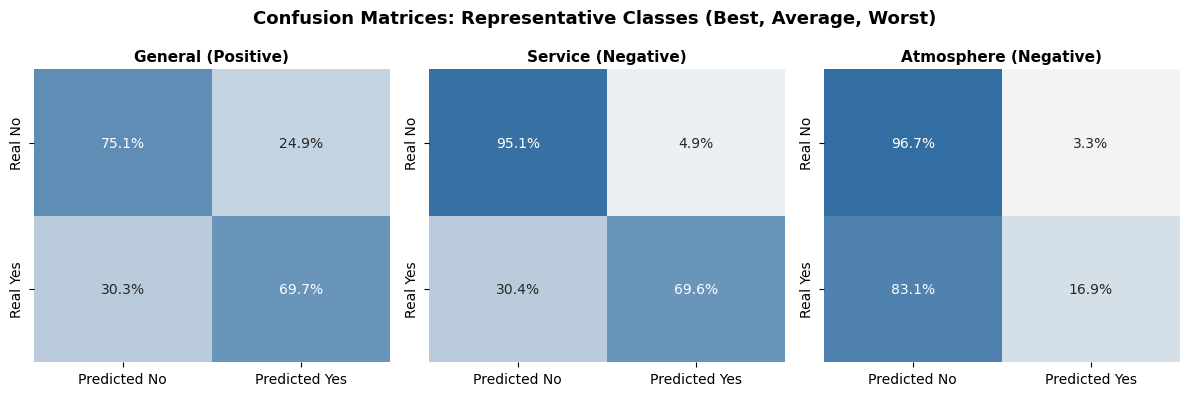

In [7]:
# Figure 6 
# RoBERTa Confusion Matrices

# Compute on validation set
mcm = multilabel_confusion_matrix(y_true_val, y_pred_val)

cmap = LinearSegmentedColormap.from_list('custom', ['#f7f7f7', '#2d6a9f'])
selected = ['general_positive', 'service_negative', 'atmosphere_negative']
titles   = ['General (Positive)', 'Service (Negative)', 'Atmosphere (Negative)']

selected_idx = [aspect_cols.index(s) for s in selected]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, idx, title in zip(axes, selected_idx, titles):
    tn, fp, fn, tp = mcm[idx].ravel()
    cm_data = np.array([[tn, fp], [fn, tp]])
    cm_pct = cm_data / cm_data.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax, cmap=cmap,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Real No', 'Real Yes'],
                cbar=False, vmin=0, vmax=100)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for text in ax.texts:
        text.set_text(text.get_text() + '%')

plt.suptitle('Confusion Matrices: Representative Classes (Best, Average, Worst)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/figure6_roberta_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 6 (RoBERTa confusion matrices):

- Service negative and general positive both achieve 69-70% recall, consistent with TF-IDF, suggesting the label noise ceiling rather than model limitations
- Atmosphere negative remains the hardest label at only 16.9% recall, nearly identical to TF-IDF's 17%, indicating contextual representations alone cannot overcome the ambiguity in this label

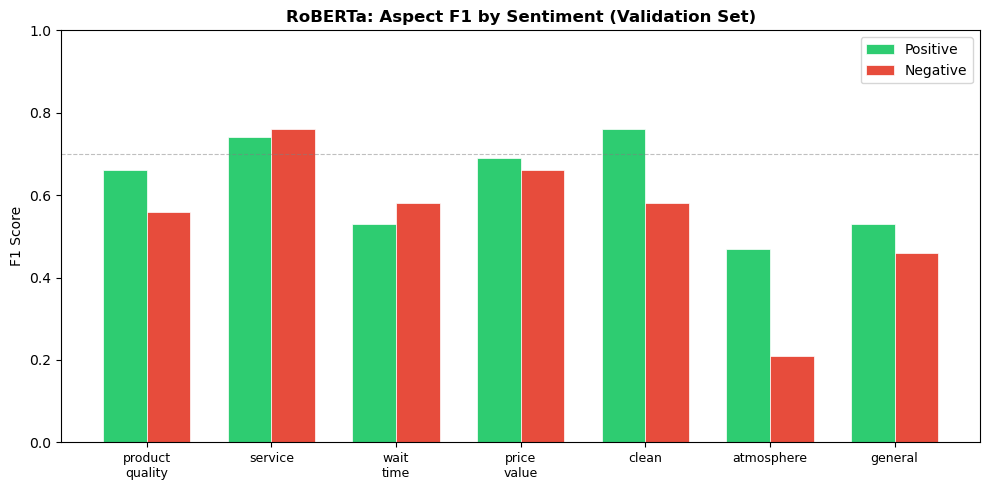

In [8]:
# Figure 7 
# RoBERTa Aspect F1 by Sentiment (100k Best Run)

aspects = ['product\nquality', 'service', 'wait\ntime', 'price\nvalue', 'clean', 'atmosphere', 'general']
pos_f1  = [0.66, 0.74, 0.53, 0.69, 0.76, 0.47, 0.53]
neg_f1  = [0.56, 0.76, 0.58, 0.66, 0.58, 0.21, 0.46]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(aspects))
width = 0.35
ax.bar(x - width/2, pos_f1, width, label='Positive', color='#2ecc71', edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, neg_f1, width, label='Negative', color='#e74c3c', edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(aspects, fontsize=9)
ax.set_ylim(0.0, 1.0)
ax.set_title('RoBERTa: Aspect F1 by Sentiment (Validation Set)', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('../figures/figure7_roberta_aspect_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 7 (RoBERTa aspect F1 - validation):

- Service and cleanliness are the strongest aspects with both sentiments above 0.58, while atmosphere negative (F1 0.21) remains the clear outlier across both models
- RoBERTa shows modest gains over TF-IDF on most labels but the overall validation pattern is similar, suggesting label noise is the primary limiting factor rather than model architecture